In [2]:
import sklearn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df= pd.read_csv("C:/Users/نورهان/OneDrive/Documents/PhD/AI & Machine Learning/AI and ML COurse/Final Project/Project Files/Raw data hcc.csv")
df


,Gender,Symptoms,Alcohol,HBsAg,HBeAg,HBcAb,HCVAb,Cirrhosis,Endemic Country,Smoking,...,ALP,Total Protein,Creatinine,Nodule,Major_Dim,Direct Bilirubin,Iron,Oxygen Saturation,Ferritin,Class
0,1,0,1,0,0,0,0,1,0,1,...,150,7.1,0.7,1,3.5,0.5,?,?,?,1
1,0,?,0,0,0,0,1,1,?,?,...,?,?,?,1,1.8,?,?,?,?,1
2,1,0,1,1,0,1,0,1,0,1,...,109,7,2.1,5,13,0.1,28,6,16,1
3,1,1,1,0,0,0,0,1,0,1,...,174,8.1,1.11,2,15.7,0.2,?,?,?,0
4,1,1,1,1,0,1,0,1,0,1,...,109,6.9,1.8,1,9,?,59,15,22,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
160,0,0,1,?,?,?,1,1,0,1,...,109,7.6,0.7,5,3,?,?,?,?,1
161,0,1,0,?,?,?,?,1,0,0,...,280,6.7,0.7,1,2.2,2.3,?,?,?,0
162,1,0,1,0,0,0,0,1,0,1,...,181,7.5,1.46,5,18.6,?,?,?,?,1
163,1,0,1,1,0,1,1,1,1,1,...,170,8.4,0.74,5,18,?,?,?,?,0


In [4]:
df.shape

(165, 50)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 165 entries, 0 to 164
Data columns (total 50 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Gender                      165 non-null    int64
 1   Symptoms                    165 non-null    str  
 2   Alcohol                     165 non-null    int64
 3   HBsAg                       165 non-null    str  
 4   HBeAg                       165 non-null    str  
 5   HBcAb                       165 non-null    str  
 6   HCVAb                       165 non-null    str  
 7   Cirrhosis                   165 non-null    int64
 8   Endemic Country             165 non-null    str  
 9   Smoking                     165 non-null    str  
 10  Diabetes                    165 non-null    str  
 11  Obesity                     165 non-null    str  
 12  Hemochromatosis             165 non-null    str  
 13  Arterial Hypertension       165 non-null    str  
 14  Chronic Renal Insuffi

In [6]:
df[df.columns[:20]].info()

<class 'pandas.DataFrame'>
RangeIndex: 165 entries, 0 to 164
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Gender                      165 non-null    int64
 1   Symptoms                    165 non-null    str  
 2   Alcohol                     165 non-null    int64
 3   HBsAg                       165 non-null    str  
 4   HBeAg                       165 non-null    str  
 5   HBcAb                       165 non-null    str  
 6   HCVAb                       165 non-null    str  
 7   Cirrhosis                   165 non-null    int64
 8   Endemic Country             165 non-null    str  
 9   Smoking                     165 non-null    str  
 10  Diabetes                    165 non-null    str  
 11  Obesity                     165 non-null    str  
 12  Hemochromatosis             165 non-null    str  
 13  Arterial Hypertension       165 non-null    str  
 14  Chronic Renal Insuffi

In [7]:
df[df.columns[20:50]].info()

<class 'pandas.DataFrame'>
RangeIndex: 165 entries, 0 to 164
Data columns (total 30 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   PVT                165 non-null    str  
 1   Metastasis         165 non-null    str  
 2   Hallmark           165 non-null    str  
 3   Age                165 non-null    int64
 4   Alcohol Grams_day  165 non-null    str  
 5   Packs_year         165 non-null    str  
 6   PS                 165 non-null    int64
 7   Encephalopathy     165 non-null    str  
 8   Ascites            165 non-null    str  
 9   INR                165 non-null    str  
 10  AFP                165 non-null    str  
 11  Hemoglobin         165 non-null    str  
 12  MCV                165 non-null    str  
 13  Leucocytes         165 non-null    str  
 14  Platelets          165 non-null    str  
 15  Albumin            165 non-null    str  
 16  Total_Bil          165 non-null    str  
 17  ALT                165 non-

In [8]:
df.replace('?', np.nan, inplace=True)
missing_values = df.isnull().sum()
missing_values

Gender                         0
Symptoms                      18
Alcohol                        0
HBsAg                         17
HBeAg                         39
HBcAb                         24
HCVAb                          9
Cirrhosis                      0
Endemic Country               39
Smoking                       41
Diabetes                       3
Obesity                       10
Hemochromatosis               23
Arterial Hypertension          3
Chronic Renal Insufficency     2
HIV                           14
NASH                          22
Varices                       52
Splenomegaly                  15
PHT                           11
PVT                            3
Metastasis                     4
Hallmark                       2
Age                            0
Alcohol Grams_day             48
Packs_year                    53
PS                             0
Encephalopathy                 1
Ascites                        2
INR                            4
AFP       

In [9]:
print(missing_values[missing_values > 0].sort_values(ascending=False))

Ferritin                      80
Oxygen Saturation             80
Iron                          79
Packs_year                    53
Varices                       52
Alcohol Grams_day             48
Direct Bilirubin              44
Smoking                       41
Endemic Country               39
HBeAg                         39
HBcAb                         24
Hemochromatosis               23
NASH                          22
Major_Dim                     20
Symptoms                      18
HBsAg                         17
Splenomegaly                  15
HIV                           14
PHT                           11
Total Protein                 11
Obesity                       10
HCVAb                          9
AFP                            8
Creatinine                     7
Albumin                        6
Total_Bil                      5
INR                            4
ALT                            4
Metastasis                     4
Platelets                      3
Diabetes  

In [10]:
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [11]:
df.describe()

,Gender,Symptoms,Alcohol,HBsAg,HBeAg,HBcAb,HCVAb,Cirrhosis,Endemic Country,Smoking,...,ALP,Total Protein,Creatinine,Nodule,Major_Dim,Direct Bilirubin,Iron,Oxygen Saturation,Ferritin,Class
count,165.000000,147.000000,165.000000,148.000000,126.000000,141.000000,156.000000,165.000000,126.000000,124.000000,...,162.000000,154.000000,158.000000,163.000000,145.000000,121.000000,86.000000,85.000000,85.000000,165.000000
mean,0.806061,0.639456,0.739394,0.108108,0.007937,0.269504,0.217949,0.903030,0.079365,0.508065,...,212.211605,8.961039,1.127089,2.736196,6.851172,1.930000,85.598837,37.028941,438.997647,0.618182
std,0.396586,0.481800,0.440302,0.311571,0.089087,0.445284,0.414182,0.296817,0.271387,0.501963,...,167.943548,11.728739,0.955856,1.797901,5.095042,4.210452,55.698995,28.993552,457.114454,0.487311
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.280000,3.900000,0.200000,0.000000,1.500000,0.100000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,...,108.250000,6.300000,0.700000,1.000000,3.000000,0.370000,40.500000,16.000000,84.000000,0.000000
50%,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,...,162.000000,7.050000,0.850000,2.000000,5.000000,0.700000,83.000000,27.000000,295.000000,1.000000
75%,1.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,...,261.500000,7.575000,1.100000,5.000000,9.000000,1.400000,118.000000,56.000000,706.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,980.000000,102.000000,7.600000,5.000000,22.000000,29.300000,224.000000,126.000000,2230.000000,1.000000


In [12]:
from sklearn.model_selection import train_test_split
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.compose import ColumnTransformer
X = df.drop(columns=['Class'])
y = df['Class']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
binary_cols = [col for col in X_train.columns if set(X_train[col].dropna().unique()).issubset({0.0, 1.0})]
numeric_cols = [col for col in X_train.columns if col not in binary_cols]
preprocessor = ColumnTransformer(
    transformers=[
        ('bin', SimpleImputer(strategy='most_frequent'), binary_cols),
        ('num', KNNImputer(n_neighbors=5), numeric_cols)
    ])
X_train_imputed = preprocessor.fit_transform(X_train)
X_test_imputed = preprocessor.transform(X_test)
all_cols = binary_cols + numeric_cols
X_train = pd.DataFrame(X_train_imputed, columns=all_cols, index=X_train.index)
X_test = pd.DataFrame(X_test_imputed, columns=all_cols, index=X_test.index)
for col in binary_cols:
    X_train[col] = X_train[col].round()
    X_test[col] = X_test[col].round()

print("Data Split and Imputed Successfully!")

Data Split and Imputed Successfully!


In [13]:
print("Missing in Train:", X_train.isnull().sum().sum())
print("Missing in Test:", X_test.isnull().sum().sum())

Missing in Train: 0
Missing in Test: 0


In [14]:
X_train.head()

,Gender,Symptoms,Alcohol,HBsAg,HBeAg,HBcAb,HCVAb,Cirrhosis,Endemic Country,Smoking,...,GGT,ALP,Total Protein,Creatinine,Nodule,Major_Dim,Direct Bilirubin,Iron,Oxygen Saturation,Ferritin
94,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,...,86.0,91.0,6.9,1.90,5.0,2.0,0.926,53.0,21.0,278.0
60,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,...,125.0,100.0,7.5,0.90,5.0,3.5,0.500,70.2,35.6,362.0
108,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,80.0,163.0,6.1,0.67,5.0,20.0,0.500,131.0,78.0,1316.0
39,1.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,...,924.0,288.0,7.9,0.98,5.0,17.0,0.600,80.8,44.8,664.6
107,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,76.0,86.0,6.3,2.68,1.0,10.0,0.400,9.0,3.0,490.0


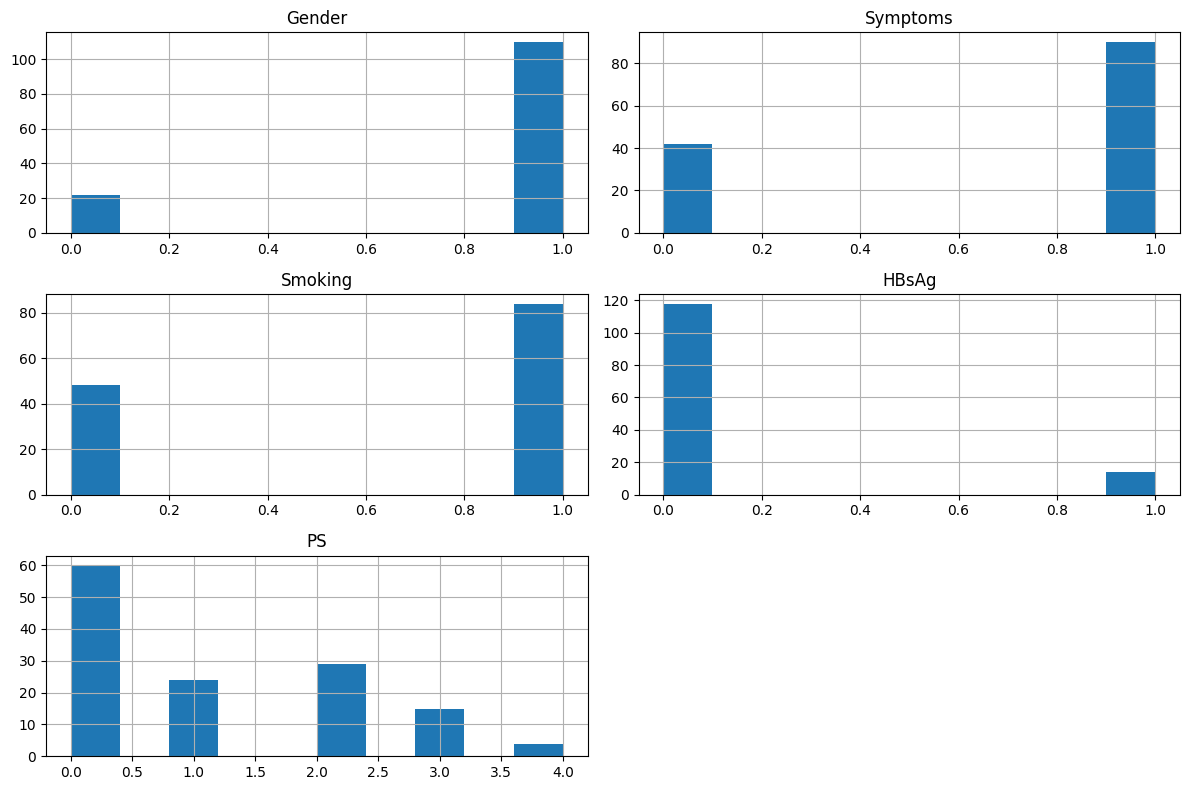

In [15]:
X_train[['Gender', 'Symptoms', 'Smoking', 'HBsAg', 'PS']].hist(figsize=(12, 8))
plt.tight_layout()
plt.show()

In [16]:
def calculate_child_pugh(row):
    score = 0
    if row['Total_Bil'] < 2.0: score += 1
    elif 2.0 <= row['Total_Bil'] <= 3.0: score += 2
    else: score += 3
        
    if row['Albumin'] > 3.5: score += 1
    elif 2.8 <= row['Albumin'] <= 3.5: score += 2
    else: score += 3
        
    if row['INR'] < 1.7: score += 1
    elif 1.7 <= row['INR'] <= 2.3: score += 2
    else: score += 3
        
    if row['Ascites'] == 1: score += 1
    elif row['Ascites'] == 2: score += 2
    elif row['Ascites'] >= 3: score += 3
    else: score += 1
        
    if row['Encephalopathy'] == 1: score += 1
    elif row['Encephalopathy'] == 2: score += 2
    elif row['Encephalopathy'] >= 3: score += 3
    else: score += 1
    return score

def feature_engineering(X_df):
    X_df = X_df.copy()
    X_df['ALBI_Score'] = (np.log10(X_df['Total_Bil'] * 17.1) * 0.66) - ((X_df['Albumin'] * 10) * 0.085)
    X_df['FIB4_Score'] = (X_df['Age'] * X_df['AST']) / ((X_df['Platelets'] / 1000) * np.sqrt(X_df['ALT']))
    X_df['AST_ALT_Ratio'] = X_df['AST'] / X_df['ALT']
    X_df['Child_Pugh_Score'] = X_df.apply(calculate_child_pugh, axis=1)
    
    comorbidity_cols = ['Diabetes', 'Obesity', 'Arterial Hypertension', 'Chronic Renal Insufficency', 'HIV']
    X_df['Comorbidities_Count'] = X_df[comorbidity_cols].sum(axis=1)
    X_df = X_df.drop(columns=comorbidity_cols)
    return X_df

X_train = feature_engineering(X_train)
X_test = feature_engineering(X_test)

In [17]:
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

# 1. Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. SMOTE
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print("Shape of Train after SMOTE:", X_train_resampled.shape)
print("Shape of Test:", X_test_scaled.shape)

Shape of Train after SMOTE: (164, 49)
Shape of Test: (33, 49)


In [18]:
df['Class'].value_counts()

Class
1    102
0     63
Name: count, dtype: int64

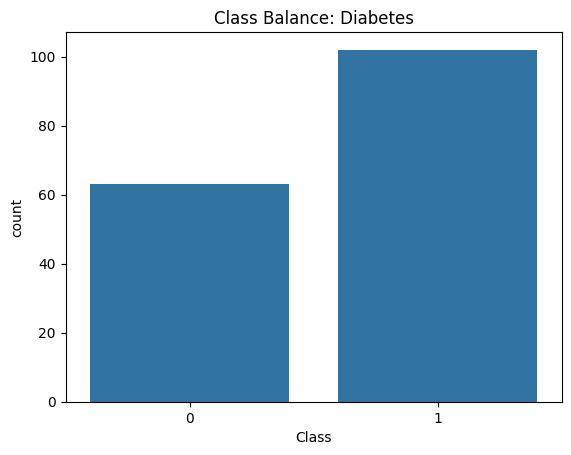

In [19]:
import seaborn as sns
sns.countplot(x='Class', data=df)
plt.title('Class Balance: Diabetes')
plt.show()

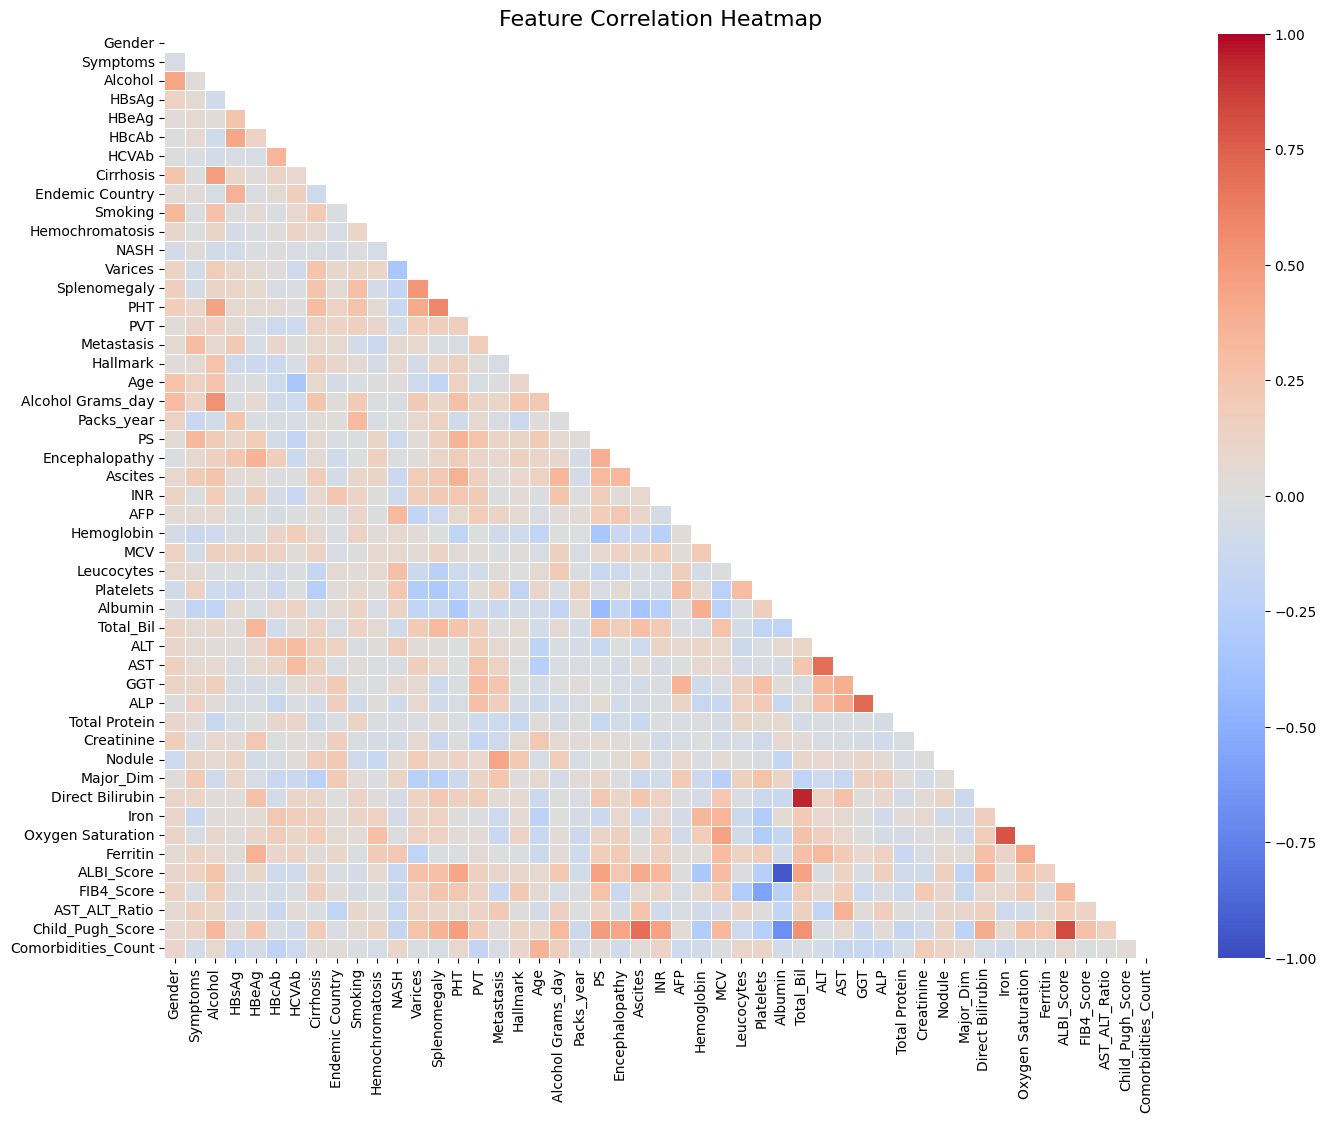

Direct Bilirubin & Total_Bil: 0.94
ALBI_Score & Albumin: -0.94
Child_Pugh_Score & ALBI_Score: 0.82


In [20]:
X_train_df = pd.DataFrame(X_train_resampled, columns=X_train.columns)
corr_matrix = X_train_df.corr()

plt.figure(figsize=(16, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=False, cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=16)
plt.show()

threshold = 0.8
high_corr_pairs = []

for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if abs(corr_matrix.iloc[i, j]) > threshold:
            colname_1 = corr_matrix.columns[i]
            colname_2 = corr_matrix.columns[j]
            corr_value = corr_matrix.iloc[i, j]
            high_corr_pairs.append((colname_1, colname_2, corr_value))

if not high_corr_pairs:
    print("No high correlation pairs found.")
else:
    for pair in high_corr_pairs:
        print(f"{pair[0]} & {pair[1]}: {pair[2]:.2f}")

In [21]:
columns_to_drop = ['Albumin', 'Direct Bilirubin', 'Child_Pugh_Score']

X_train_reduced = X_train_df.drop(columns=columns_to_drop)

X_test_df = pd.DataFrame(X_test_scaled, columns=X_train.columns)
X_test_reduced = X_test_df.drop(columns=columns_to_drop)

In [22]:
# Model 1: Logistic Regression

In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_reduced, y_train_resampled)
y_pred = log_reg.predict(X_test_reduced)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.7878787878787878

Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.69      0.72        13
           1       0.81      0.85      0.83        20

    accuracy                           0.79        33
   macro avg       0.78      0.77      0.77        33
weighted avg       0.79      0.79      0.79        33


Confusion Matrix:
 [[ 9  4]
 [ 3 17]]


In [24]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

lr_params = {'C': [0.01, 0.1, 1, 10, 100], 'penalty': ['l2'], 'solver': ['lbfgs', 'liblinear']}
grid_lr = GridSearchCV(LogisticRegression(max_iter=1000, random_state=42), lr_params, cv=5)
grid_lr.fit(X_train_reduced, y_train_resampled)
y_pred_lr_tuned = grid_lr.predict(X_test_reduced)
print("Best LR Params:", grid_lr.best_params_)
print("Accuracy:", accuracy_score(y_test, y_pred_lr_tuned))
print(classification_report(y_test, y_pred_lr_tuned))

c:\Users\نورهان\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\نورهان\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\نورهان\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was d

Best LR Params: {'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'}
Accuracy: 0.7575757575757576
              precision    recall  f1-score   support

           0       0.69      0.69      0.69        13
           1       0.80      0.80      0.80        20

    accuracy                           0.76        33
   macro avg       0.75      0.75      0.75        33
weighted avg       0.76      0.76      0.76        33



c:\Users\نورهان\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\نورهان\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\نورهان\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was d

In [25]:
# Model2: DT

In [26]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_reduced, y_train_resampled)
y_pred_dt = dt_model.predict(X_test_reduced)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print("\nClassification Report:\n", classification_report(y_test, y_pred_dt))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))

print("\nTrain Accuracy:", accuracy_score(y_train_resampled, dt_model.predict(X_train_reduced)))
print("Test Accuracy:", accuracy_score(y_test, y_pred_dt))

Decision Tree Accuracy: 0.5757575757575758

Classification Report:
               precision    recall  f1-score   support

           0       0.45      0.38      0.42        13
           1       0.64      0.70      0.67        20

    accuracy                           0.58        33
   macro avg       0.55      0.54      0.54        33
weighted avg       0.56      0.58      0.57        33


Confusion Matrix:
 [[ 5  8]
 [ 6 14]]

Train Accuracy: 1.0
Test Accuracy: 0.5757575757575758


In [27]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

param_grid = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy'
)

grid_search.fit(X_train_reduced, y_train_resampled)

print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation Accuracy:", grid_search.best_score_)

Best Parameters: {'criterion': 'gini', 'max_depth': 7, 'min_samples_leaf': 4, 'min_samples_split': 10}
Best Cross-Validation Accuracy: 0.7263257575757576


In [28]:
best_dt = DecisionTreeClassifier(
    criterion='gini',
    max_depth=7,
    min_samples_leaf=1,
    min_samples_split=5,
    random_state=42
)
best_dt.fit(X_train_reduced, y_train_resampled)

y_pred_best = best_dt.predict(X_test_reduced)

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
print("Test Accuracy:", accuracy_score(y_test, y_pred_best))
print("\nClassification Report:\n", classification_report(y_test, y_pred_best))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_best))

Test Accuracy: 0.6363636363636364

Classification Report:
               precision    recall  f1-score   support

           0       0.54      0.54      0.54        13
           1       0.70      0.70      0.70        20

    accuracy                           0.64        33
   macro avg       0.62      0.62      0.62        33
weighted avg       0.64      0.64      0.64        33


Confusion Matrix:
 [[ 7  6]
 [ 6 14]]


In [29]:
# Model 3: Random forest

Random Forest Accuracy: 0.7878787878787878

Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.69      0.72        13
           1       0.81      0.85      0.83        20

    accuracy                           0.79        33
   macro avg       0.78      0.77      0.77        33
weighted avg       0.79      0.79      0.79        33


Confusion Matrix:
 [[ 9  4]
 [ 3 17]]


C:\Users\نورهان\AppData\Local\Temp\ipykernel_23144\3599923567.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feat_imp_df, palette='viridis')


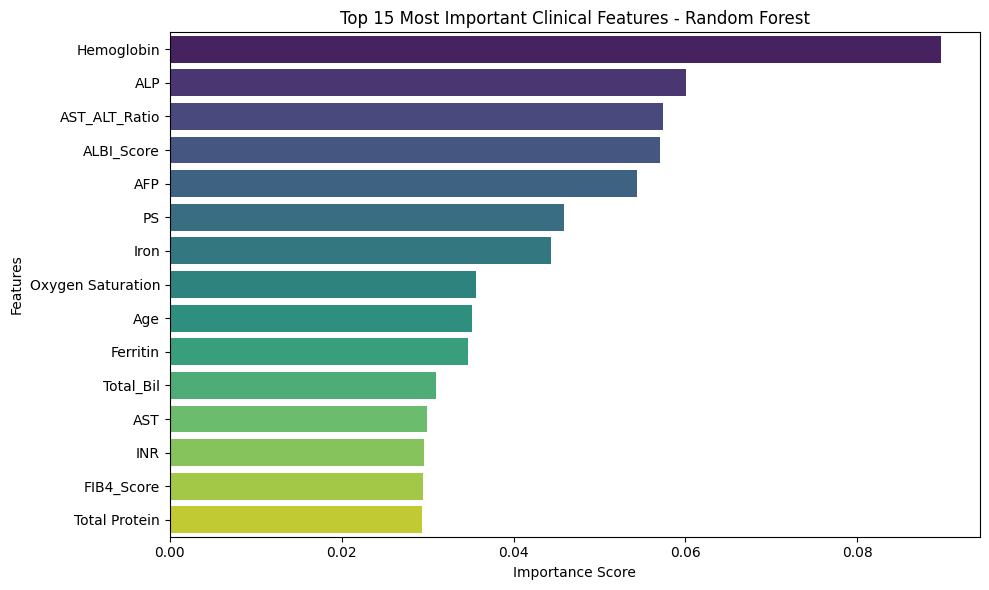

In [30]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
rf_model = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced')
rf_model.fit(X_train_reduced, y_train_resampled)
y_pred_rf = rf_model.predict(X_test_reduced)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

importances = rf_model.feature_importances_
features = X_train_reduced.columns 
feat_imp_df = pd.DataFrame({'Feature': features, 'Importance': importances})
feat_imp_df = feat_imp_df.sort_values(by='Importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feat_imp_df, palette='viridis')
plt.title('Top 15 Most Important Clinical Features - Random Forest')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

In [31]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

rf_params = {'n_estimators': [50, 100, 200], 'max_depth': [None, 5, 10, 20], 'min_samples_split': [2, 5, 10]}
grid_rf = GridSearchCV(RandomForestClassifier(random_state=42, class_weight='balanced'), rf_params, cv=5)
grid_rf.fit(X_train_reduced, y_train_resampled)
y_pred_rf_tuned = grid_rf.predict(X_test_reduced)
print("Best RF Params:", grid_rf.best_params_)
print("Accuracy:", accuracy_score(y_test, y_pred_rf_tuned))
print(classification_report(y_test, y_pred_rf_tuned))

Best RF Params: {'max_depth': None, 'min_samples_split': 10, 'n_estimators': 50}
Accuracy: 0.7878787878787878
              precision    recall  f1-score   support

           0       0.75      0.69      0.72        13
           1       0.81      0.85      0.83        20

    accuracy                           0.79        33
   macro avg       0.78      0.77      0.77        33
weighted avg       0.79      0.79      0.79        33



In [32]:
# Model 4: G-Booster

In [33]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train_reduced, y_train_resampled)
y_pred_gb = gb_model.predict(X_test_reduced)

print("Accuracy:", accuracy_score(y_test, y_pred_gb))
print(classification_report(y_test, y_pred_gb))

Accuracy: 0.8181818181818182
              precision    recall  f1-score   support

           0       0.89      0.62      0.73        13
           1       0.79      0.95      0.86        20

    accuracy                           0.82        33
   macro avg       0.84      0.78      0.80        33
weighted avg       0.83      0.82      0.81        33



In [34]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report

gb_params = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 1.0]
}

grid_gb = GridSearchCV(GradientBoostingClassifier(random_state=42), gb_params, cv=5, scoring='accuracy')
grid_gb.fit(X_train_reduced, y_train_resampled)

y_pred_gb_tuned = grid_gb.predict(X_test_reduced)

print("Best GB Params:", grid_gb.best_params_)
print("Accuracy:", accuracy_score(y_test, y_pred_gb_tuned))
print(classification_report(y_test, y_pred_gb_tuned))

Best GB Params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}
Accuracy: 0.7878787878787878
              precision    recall  f1-score   support

           0       0.80      0.62      0.70        13
           1       0.78      0.90      0.84        20

    accuracy                           0.79        33
   macro avg       0.79      0.76      0.77        33
weighted avg       0.79      0.79      0.78        33



In [35]:
# Model 5: SVC

In [36]:
from sklearn.svm import SVC

svc_model = SVC(kernel='rbf', probability=True, random_state=42)
svc_model.fit(X_train_reduced, y_train_resampled)
y_pred_svc = svc_model.predict(X_test_reduced)

print("Accuracy:", accuracy_score(y_test, y_pred_svc))
print(classification_report(y_test, y_pred_svc))

Accuracy: 0.7272727272727273
              precision    recall  f1-score   support

           0       0.75      0.46      0.57        13
           1       0.72      0.90      0.80        20

    accuracy                           0.73        33
   macro avg       0.73      0.68      0.69        33
weighted avg       0.73      0.73      0.71        33



In [37]:
## Voting Classifier (Best Model)

In [38]:
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
clf1 = LogisticRegression(max_iter=1000, random_state=42, C=1)
clf2 = GradientBoostingClassifier(n_estimators=100, learning_rate=0.05, max_depth=3, subsample=0.8, random_state=42)
voting_model = VotingClassifier(estimators=[('lr', clf1), ('gb', clf2)], voting='soft')
voting_model.fit(X_train_reduced, y_train_resampled)
y_pred_voting = voting_model.predict(X_test_reduced)

print("Voting Classifier Accuracy:", accuracy_score(y_test, y_pred_voting))
print("\nClassification Report:\n", classification_report(y_test, y_pred_voting))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_voting))

Voting Classifier Accuracy: 0.8181818181818182

Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.77      0.77        13
           1       0.85      0.85      0.85        20

    accuracy                           0.82        33
   macro avg       0.81      0.81      0.81        33
weighted avg       0.82      0.82      0.82        33


Confusion Matrix:
 [[10  3]
 [ 3 17]]


In [39]:
import joblib

joblib.dump(voting_model, 'hcc_voting_model.pkl')
joblib.dump(scaler, 'hcc_scaler.pkl')
final_features = X_train_reduced.columns.tolist()
joblib.dump(final_features, 'hcc_features.pkl')
print("Model, Scaler, and Features saved successfully! Ready for deployment.")

Model, Scaler, and Features saved successfully! Ready for deployment.


In [40]:
import joblib

joblib.dump(voting_model, 'hcc_voting_model.pkl')
joblib.dump(scaler, 'hcc_scaler.pkl')

final_features = X_train_reduced.columns.tolist()
joblib.dump(final_features, 'hcc_features.pkl')

print(f"Total features expected: {len(final_features)}")

Total features expected: 46
